<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Semanal Nº3: Desparramo Espectral (Spectral Leakage)
#### Ivana Rocio Miranda


## Introducción Teórica

La **Transformada Discreta de Fourier (DFT)** permite analizar el contenido frecuencial de una señal discreta de longitud finita $N$. Dado que la DFT asume que la señal es **periódica** con período $N$, cuando la frecuencia de la señal **no es un múltiplo exacto** de la resolución frecuencial $\Delta_f = f_S / N$, se produce el fenómeno conocido como **desparramo espectral** (*spectral leakage*).

Este fenómeno consiste en que la energía de una componente sinusoidal, que idealmente debería concentrarse en un único bin frecuencial, se "derrama" hacia los bins vecinos, distorsionando el espectro observado.

### Resolución frecuencial

La resolución en frecuencia de la DFT está dada por:
$$\Delta_f = \frac{f_S}{N}$$
donde $f_S$ es la frecuencia de muestreo y $N$ es el número de muestras. La frecuencia de cada bin es:
$$f_k = k \cdot \Delta_f, \quad k = 0, 1, \ldots, N-1$$

### Condición de Desparramo Espectral (Spectral Leakage)

Si la frecuencia de la señal $f_0$ es **exactamente** un múltiplo entero de $\Delta_f$ (es decir, $f_0 = k_0 \cdot \Delta_f$ con $k_0 \in \mathbb{Z}$), no hay desparramo: toda la energía cae en un único bin. Si $f_0$ no satisface esta condición, aparece el desparramo.

### Identidad de Parseval

La identidad de Parseval relaciona la energía en el dominio temporal con la energía en el dominio frecuencial:
$$\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$
Esto permite verificar que la potencia total de la señal se conserva independientemente del desparramo.

### Zero Padding

El *zero padding* consiste en agregar ceros al final de la señal antes de calcular la DFT. Esto **no agrega información nueva** al espectro, pero aumenta la resolución frecuencial de forma ficticia (interpola el espectro), permitiendo visualizar con mayor detalle la forma de los lóbulos espectrales.


## Función generadora de señal senoidal e importaciones

Se define una función auxiliar que genera una señal senoidal con los parámetros deseados: amplitud máxima, componente de continua (DC), frecuencia, fase inicial, número de muestras y frecuencia de muestreo.

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts=1/fs
    tt= np.arange(0,nn)*ts
    xx= dc + vmax*np.sin(2*np.pi*ff*tt + ph)
    
    return tt, xx

## Parámetros del experimento

Se define la frecuencia de muestreo $f_S = 1000$ Hz y el número de muestras $N = f_S / 2 = 500$, lo que determina la resolución frecuencial $\Delta_f = f_S / N = 2$ Hz.

Las tres frecuencias bajo análisis son:
- $f_1 = f_S/4$ → exactamente en un bin de la DFT (sin desparramo)
- $f_2 = \Delta_f \cdot (N/4 + 0.25)$ → desintonía de 0.25 bins
- $f_3 = \Delta_f \cdot (N/4 + 0.50)$ → desintonía de 0.5 bins (máximo desparramo para este caso)

In [28]:
fs= 1000 #ancho de banda
N = fs//2
df = fs/N
ffn=np.arange(N)*df
bBool=ffn<=fs/2
frec = np.arange(0, fs/2, df) #EJE DE FRECUENCIA (HECHO A MANO)
f1 = fs/4
f2 = (fs/N)*((N/4)+0.25)
f3 = (fs/N)*((N/4)+0.50)

---
# Inciso a) — Densidades Espectrales de Potencia (PSD)

Se generan tres señales sinusoidales con **potencia normalizada** (varianza unitaria). Para una sinusoide $x(t) = V_{max} \sin(2\pi f t)$, la potencia es $P = V_{max}^2/2$. Para tener potencia unitaria se elige $V_{max} = \sqrt{2}$.

Luego se calcula la FFT de cada señal, se obtiene el módulo al cuadrado (que representa la PSD) y se grafica en escala logarítmica (dB).

**Efecto esperado:** La señal $x_1$ (frecuencia exactamente en un bin) presenta un espectro concentrado en un único punto. Las señales $x_2$ y $x_3$ exhiben desparramo creciente: la energía se distribuye entre varios bins vecinos al bin central.

In [4]:
tt, x1 = mi_funcion_sen(vmax = np.sqrt(2), dc = 0, ff = f1, ph=0, nn = N, fs = fs) 
tt, x2 = mi_funcion_sen(vmax = np.sqrt(2), dc = 0, ff = f2, ph=0, nn = N, fs = fs) 
tt, x3 = mi_funcion_sen(vmax = np.sqrt(2), dc = 0, ff = f3, ph=0, nn = N, fs = fs) 

In [5]:
# FFT
X1 = np.fft.fft(x1) / N
X2 = np.fft.fft(x2) / N
X3 = np.fft.fft(x3) / N
# Módulos
XXmod1 = np.abs(X1)**2 
XXmod2 = np.abs(X2)**2
XXmod3 = np.abs(X3)**2
# Modulos en Db
XXmod1DB = 10*np.log10(XXmod1)
XXmod2DB = 10*np.log10(XXmod2)
XXmod3DB = 10*np.log10(XXmod3)

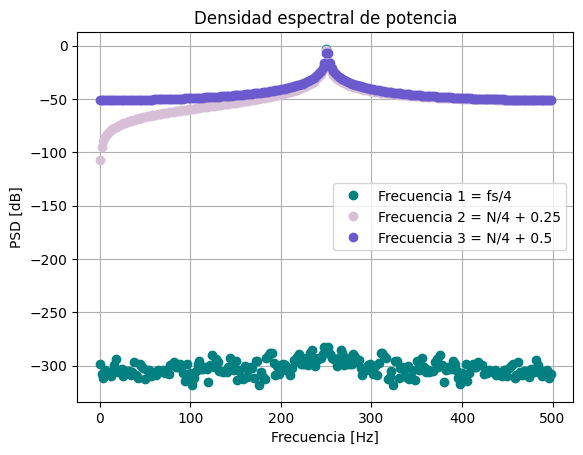

In [6]:
# Grafico de módulo 
plt.figure()
plt.plot(frec, XXmod1DB[:N//2], 'o', color="teal", label="Frecuencia 1 = fs/4")
plt.plot(frec, XXmod2DB[:N//2], 'o', color="thistle", label="Frecuencia 2 = N/4 + 0.25")
plt.plot(frec, XXmod3DB[:N//2], 'o', color="slateblue", label="Frecuencia 3 = N/4 + 0.5")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.title("Densidad espectral de potencia")
plt.grid()
plt.legend()
plt.show()

### Densidades espectrales de potencia individuales (zoom en zona de interés)

Se grafican las PDS de cada frecuencia por separado, haciendo zoom en la banda de 220–280 Hz para apreciar mejor el efecto del desparramo.

- **$f_1$**: Concentra toda su energía en un único bin. Ideal, sin desparramo.
- **$f_2$**: Con 0.25 bins de desintonía, ya comienza a "esparcirse" la energía a bins adyacentes.
- **$f_3$**: Con 0.5 bins de desintonía (máxima para este experimento), el desparramo es notoriamente mayor: el pico principal es menor y más ancho, y aparecen lóbulos laterales significativos.

/tmp/ipykernel_7158/1476028083.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_7158/1476028083.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_7158/1476028083.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


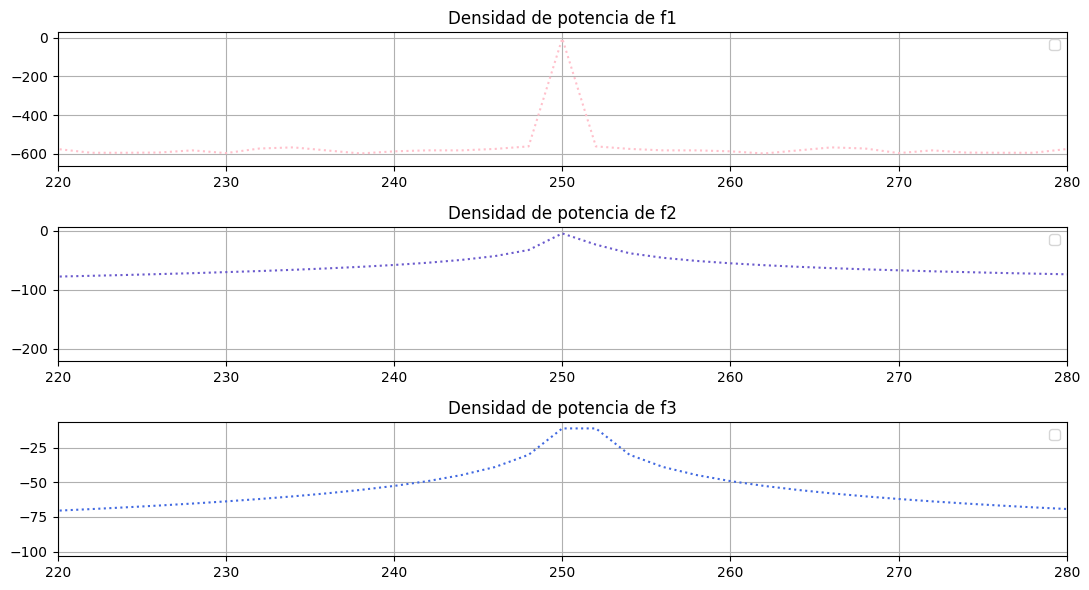

In [31]:
# Densidad espectral de potencias
Potencia1 = (XXmod1**2)*2
pot_dB1=10*np.log10(Potencia1)
Potencia2 = (XXmod2**2)*2
pot_dB2=10*np.log10(Potencia2)
Potencia3 = (XXmod3**2)*2
pot_dB3=10*np.log10(Potencia3)

# Graficos de la potencia 
plt.figure(figsize=(11,6))
plt.subplot(3,1,1)
plt.xlim(220, 280)
plt.plot(ffn[bBool], pot_dB1[bBool], color = 'pink',  linestyle = ':' )
plt.title("Densidad de potencia de f1")
plt.legend()
plt.grid()
plt.subplot(3,1,2)
plt.xlim(220, 280)
plt.plot(ffn[bBool], pot_dB2[bBool], color = 'slateblue',  linestyle = ':' )
plt.title("Densidad de potencia de f2")
plt.legend()
plt.grid()
plt.subplot(3,1,3)
plt.xlim(220, 280)
plt.plot(ffn[bBool], pot_dB3[bBool], color = 'royalblue',  linestyle = ':' )
plt.title("Densidad de potencia de f3")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

---
# Inciso b) — Verificación de potencia unitaria mediante Parseval

La **identidad de Parseval** establece que la energía total de la señal se conserva en la transformada. Para una señal con potencia normalizada (varianza unitaria), la suma de los coeficientes de la PDS debe ser igual a 1.

**¿Por qué dos señales muy cercanas en frecuencia pueden tener espectros tan distintos?**  
La razón es que la DFT es una proyección sobre una base de sinusoides cuya frecuencia es exactamente $k \cdot \Delta_f$. Cuando $f_0$ no coincide exactamente con ningún bin, la proyección se distribuye entre muchos coeficientes en lugar de concentrarse en uno solo. Incluso una desintonía de apenas 0.25 o 0.5 Hz (en este caso 0.5 o 1 Hz) puede generar diferencias visuales drásticas en la PDS, aunque la potencia total se mantiene constante.

In [32]:
# Verificación de potencia unitaria por Parseval
# Potencia en el dominio del tiempo
pot_tiempo1 = np.mean(x1**2)
pot_tiempo2 = np.mean(x2**2)
pot_tiempo3 = np.mean(x3**2)

# Potencia en el dominio de la frecuencia (Parseval)
pot_frec1 = np.sum(np.abs(np.fft.fft(x1))**2) / N**2
pot_frec2 = np.sum(np.abs(np.fft.fft(x2))**2) / N**2
pot_frec3 = np.sum(np.abs(np.fft.fft(x3))**2) / N**2

print("=== Verificación de Parseval ===")
print(f"Señal x1 | Potencia tiempo: {pot_tiempo1:.4f} | Potencia frecuencia: {pot_frec1:.4f}")
print(f"Señal x2 | Potencia tiempo: {pot_tiempo2:.4f} | Potencia frecuencia: {pot_frec2:.4f}")
print(f"Señal x3 | Potencia tiempo: {pot_tiempo3:.4f} | Potencia frecuencia: {pot_frec3:.4f}")

=== Verificación de Parseval ===
Señal x1 | Potencia tiempo: 1.0000 | Potencia frecuencia: 1.0000
Señal x2 | Potencia tiempo: 0.9980 | Potencia frecuencia: 0.9980
Señal x3 | Potencia tiempo: 1.0000 | Potencia frecuencia: 1.0000


Los valores de potencia en el dominio temporal y frecuencial deben ser iguales (o muy cercanos) para las tres señales, confirmando la identidad de Parseval. La potencia es unitaria en todos los casos, independientemente del grado de desparramo observado visualmente en el espectro.

---
# Inciso c) — Experimento con Zero Padding

El *zero padding* consiste en concatenar un vector de ceros al final de la señal original antes de aplicar la DFT. En este experimento se agrega un vector de $9N$ ceros, llevando la longitud total a $9N$ muestras.

**Efecto del zero padding:**  
- La resolución frecuencial "ficticia" pasa a ser $\Delta_f' = f_S / (9N)$, mucho más fina.
- Permite **interpolar** el espectro y ver la forma continua del lóbulo espectral.
- **No mejora la resolución real**: dos frecuencias cercanas que no eran separables siguen sin serlo. Solo se "dibuja" con más puntos la misma función espectral subyacente.
- Para señales con desparramo ($f_2$, $f_3$), ahora se puede observar claramente la forma del lóbulo principal y los lóbulos laterales.

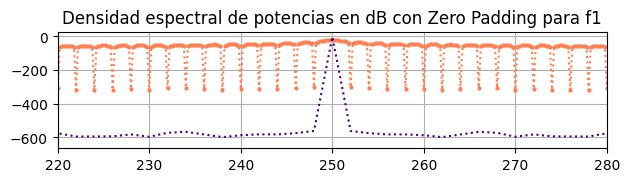

In [21]:
# ZERO PADDING de primer frecuencia
Npad = int(9*N)
ceros = np.zeros(Npad - N)
x1_pad = np.concatenate((x1, ceros))
X1_pad = np.fft.fft(x1_pad) / Npad
XXmod1_pad = np.abs(X1_pad)
DEP_pad1 = (XXmod1_pad)**2          #Densidad espectral de potencias
DEP_pad1_dB = 10*np.log10(DEP_pad1)  #Densidad espectral de potencias en dB
df_pad = fs / Npad
ffn_pad = np.arange(Npad) * df_pad
bBool_pad = ffn_pad <= fs/2
plt.subplot(3,1,1)
plt.xlim(220, 280)
plt.plot(ffn_pad[bBool_pad], DEP_pad1_dB[bBool_pad], 'o', markersize=2, linestyle = ':',  color = 'coral' )
plt.title("Densidad espectral de potencias en dB con Zero Padding para f1")
plt.plot(ffn[bBool], pot_dB1[bBool], color = 'indigo',  linestyle = ':', label= "Potencia sin zero-padding")
plt.grid()
plt.tight_layout()
plt.show()

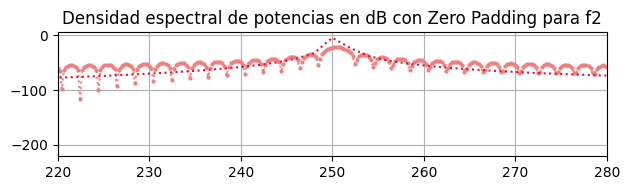

In [23]:
#ZERO PADDING de segunda frecuencia
x2_pad = np.concatenate((x2, ceros))
X2_pad = np.fft.fft(x2_pad) / Npad
XXmod2_pad = np.abs(X2_pad)
DEP_pad2 = (XXmod2_pad)**2          #Densidad espectral de potencias
DEP_pad2_dB = 10*np.log10(DEP_pad2)  #Densidad espectral de potencias en dB
plt.subplot(3,1,2)
plt.xlim(220, 280)
plt.plot(ffn_pad[bBool_pad], DEP_pad2_dB[bBool_pad], 'o', markersize=2, linestyle = ':', color = 'lightcoral' )
plt.title("Densidad espectral de potencias en dB con Zero Padding para f2")
plt.plot(ffn[bBool], pot_dB2[bBool], color = 'crimson',  linestyle = ':', label = "Potencia sin zero-padding" )
plt.grid()
plt.tight_layout()
plt.show()

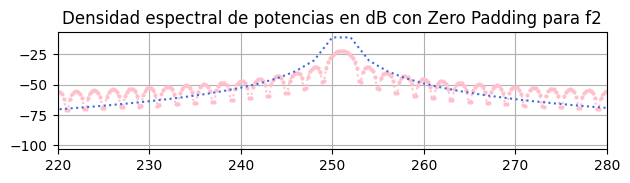

In [25]:
# ZERO PADDING de tercer frecuencia
x3_pad = np.concatenate((x3, ceros))
X3_pad = np.fft.fft(x3_pad) / Npad
XXmod3_pad = np.abs(X3_pad)
DEP_pad3 = (XXmod3_pad)**2          #Densidad espectral de potencias
DEP_pad3_dB = 10*np.log10(DEP_pad3)  #Densidad espectral de potencias en dB
plt.subplot(3,1,3)
plt.xlim(220, 280)
plt.plot(ffn_pad[bBool_pad], DEP_pad3_dB[bBool_pad], 'o', markersize=2, linestyle = ':', color = 'pink' )
plt.title("Densidad espectral de potencias en dB con Zero Padding para f2")
plt.plot(ffn[bBool], pot_dB3[bBool], color = 'royalblue',  linestyle = ':', label = "Potencia sin zero-padding")
plt.grid()
plt.tight_layout()
plt.show()

## Discusión de resultados — Zero Padding

Con el zero padding se puede apreciar que:

- **$f_1$** (sin desparramo): el espectro con zero padding muestra el lóbulo principal perfectamente centrado en el bin correcto. La interpolación permite ver la función sinc subyacente, con lóbulos laterales de baja amplitud.

- **$f_2$ y $f_3$** (con desparramo): ahora se puede visualizar claramente cómo la energía NO está concentrada en un único bin sino distribuida en un lóbulo ancho. A mayor desintonía (de $f_1$ a $f_3$), mayor es la amplitud de los lóbulos laterales y menor la del pico principal.

El zero padding es útil para **visualización** del espectro, pero no soluciona el problema de desparramo. Para mitigarlo se utilizan técnicas de **enventanado** (windowing), que reducen los lóbulos laterales a costa de ensanchar el lóbulo principal.

---
## Conclusión

El desparramo espectral es una consecuencia directa de la naturaleza discreta y finita de la DFT. Surge cuando la frecuencia de la señal no es un múltiplo entero de la resolución frecuencial $\Delta_f$. La identidad de Parseval garantiza que la potencia total se conserva, pero su distribución en el espectro varía drásticamente con pequeñas desintonías. El zero padding mejora la visualización del fenómeno pero no lo corrige.